<a href="https://colab.research.google.com/github/Abhishekj9621/AI-Assistant/blob/main/Video_Annotation_Unique_ID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install "ultralytics>=8.3.114" yt-dlp opencv-python-headless matplotlib seaborn \
             pandas numpy Pillow tqdm --quiet

import torch
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU — go to Runtime → Change runtime type → T4 GPU")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 83.8 MB/s eta 0:00:00
PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB


In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/sports_tracking_project'
os.makedirs(f'{PROJECT_DIR}/videos',      exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/outputs',     exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/screenshots', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/plots',       exist_ok=True)

print(f"✅ Project folder ready: {PROJECT_DIR}")

Mounted at /content/drive
✅ Project folder ready: /content/drive/MyDrive/sports_tracking_project


In [3]:
VIDEO_URL = "https://www.youtube.com/watch?v=aTTOQtSOX3I"

YOLO_MODEL        = "yolo12m.pt"
PRIMARY_TRACKER   = "/content/botsort_sports.yaml"
SECONDARY_TRACKER = "bytetrack.yaml"

CONF_THRESHOLD   = 0.30
IOU_THRESHOLD    = 0.45
TRACK_CLASSES    = [0]
MAX_DURATION_SEC = 60
TRAIL_LENGTH     = 60
OUTPUT_SCALE     = 1.0

import torch, os
PROJECT_DIR      = '/content/drive/MyDrive/sports_tracking_project'
RAW_VIDEO_PATH   = f'{PROJECT_DIR}/videos/raw_input.mp4'
OUTPUT_PRIMARY   = f'{PROJECT_DIR}/outputs/tracked_botsort_v2.mp4'
OUTPUT_SECONDARY = f'{PROJECT_DIR}/outputs/tracked_bytetrack_v2.mp4'
HEATMAP_PATH     = f'{PROJECT_DIR}/plots/heatmap.png'
TRAJECTORY_PATH  = f'{PROJECT_DIR}/plots/trajectory.png'
COUNT_PLOT_PATH  = f'{PROJECT_DIR}/plots/object_count_over_time.png'
SCREENSHOT_DIR   = f'{PROJECT_DIR}/screenshots'
DEVICE           = 'cuda' if torch.cuda.is_available() else 'cpu'


botsort_yaml = """\
tracker_type: botsort

# Detection thresholds
track_high_thresh: 0.25    # ← Lower from 0.30; catch more players in stage 1
track_low_thresh:  0.05    # recover lost tracks with low-conf detections
new_track_thresh:  0.35    # minimum conf to spawn a NEW track

# Increase buffer significantly — key for occlusion survival
track_buffer: 120          # ← Raise from 90 to 120 (4s at 30fps)

# Looser matching = fewer wrong ID rejections
match_thresh: 0.80         # ← Raise from 0.70 (matches official Ultralytics default)

fuse_score: True

# ── BoT-SORT specific ───────────────────────────────────────────
gmc_method: sparseOptFlow  # camera motion compensation

# ReID — native YOLO features, zero latency cost
with_reid: True
model: auto                # uses YOLO's own feature embeddings (v8.3.114+)

# ← CRITICAL FIX: these two values in your current YAML are wrong
proximity_thresh:  0.5     # IoU gate — only attempt ReID if IoU > 0.5
appearance_thresh: 0.25    # ← Lower from 0.30 to 0.25 (official default)
                           # Lower = more lenient re-ID after occlusion
"""

with open("/content/botsort_sports.yaml", "w") as f:
    f.write(botsort_yaml)

print("✅ Custom BoT-SORT YAML written to /content/botsort_sports.yaml")
print(f"✅ Config loaded | Device: {DEVICE} | Video: {VIDEO_URL}")

✅ Custom BoT-SORT YAML written to /content/botsort_sports.yaml
✅ Config loaded | Device: cuda | Video: https://www.youtube.com/watch?v=aTTOQtSOX3I


In [4]:
import subprocess, os

def download_video(url, output_path, max_duration_sec=None):
    print(f"⬇️  Downloading: {url}")
    cmd = [
        'yt-dlp',
        '-f', 'bestvideo[height<=720][ext=mp4]+bestaudio[ext=m4a]/best[height<=720][ext=mp4]/best',
        '--merge-output-format', 'mp4',
        '-o', output_path,
        '--no-playlist',
        url
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"❌ Download failed:\n{result.stderr}")
        return False
    print(f"✅ Downloaded!")

    if max_duration_sec:
        trimmed = output_path.replace('.mp4', '_tmp.mp4')
        print(f"✂️  Trimming to {max_duration_sec}s ...")
        trim = ['ffmpeg', '-y', '-i', output_path,
                '-t', str(max_duration_sec),
                '-c:v', 'libx264', '-c:a', 'aac', trimmed]
        r2 = subprocess.run(trim, capture_output=True, text=True)
        if r2.returncode == 0:
            os.replace(trimmed, output_path)
            print("✅ Trimmed!")
        else:
            print("⚠️  Trim failed — using full video")
    return True

success = download_video(VIDEO_URL, RAW_VIDEO_PATH, MAX_DURATION_SEC)

if success:
    import cv2
    cap  = cv2.VideoCapture(RAW_VIDEO_PATH)
    fps  = cap.get(cv2.CAP_PROP_FPS)
    tot  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    size_mb = os.path.getsize(RAW_VIDEO_PATH) / 1e6
    print(f"\n📹 {w}x{h}  |  {fps:.1f} FPS  |  {tot} frames ({tot/fps:.1f}s)  |  {size_mb:.1f} MB")

⬇️  Downloading: https://www.youtube.com/watch?v=aTTOQtSOX3I
✅ Downloaded!
✂️  Trimming to 60s ...
✅ Trimmed!

📹 1280x720  |  60.0 FPS  |  3600 frames (60.0s)  |  17.0 MB


In [5]:
from ultralytics import YOLO
import cv2

print(f"📦 Loading {YOLO_MODEL} ...")
model = YOLO(YOLO_MODEL)
model.to(DEVICE)
print(f"✅ Model loaded on {DEVICE}")
print(f"   Parameters : {sum(p.numel() for p in model.parameters()):,}")


cap = cv2.VideoCapture(RAW_VIDEO_PATH)
ret, test_frame = cap.read()
cap.release()
if ret:
    r = model(test_frame, verbose=False, classes=TRACK_CLASSES)
    print(f"🧪 First-frame detections: {len(r[0].boxes)} objects found")
    print("✅ Model inference working!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
📦 Loading yolo12m.pt ...
✅ Model loaded on cuda
   Parameters : 20,201,216
🧪 First-frame detections: 10 objects found
✅ Model inference working!


In [6]:
import cv2, numpy as np, colorsys
from collections import defaultdict

def get_id_color(track_id):
    """Deterministic distinct color per ID using golden-ratio hue spacing."""
    hue = (track_id * 0.618033988749895) % 1.0
    r, g, b = colorsys.hsv_to_rgb(hue, 0.92, 0.98)
    return (int(b * 255), int(g * 255), int(r * 255))

def draw_box(img, x1, y1, x2, y2, color, thickness=2):
    """Draw bounding box with corner accents for cleaner look."""
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    L = min(20, (x2-x1)//4, (y2-y1)//4)
    for px, py, dx, dy in [(x1,y1,1,1),(x2,y1,-1,1),(x1,y2,1,-1),(x2,y2,-1,-1)]:
        cv2.line(img, (px, py), (px+dx*L, py), color, thickness+1)
        cv2.line(img, (px, py), (px, py+dy*L), color, thickness+1)

def draw_id_label(img, track_id, x1, y1, color):
    """Draw pill-shaped ID badge above the bounding box."""
    label = f" ID:{track_id} "
    font  = cv2.FONT_HERSHEY_DUPLEX
    scale, thick = 0.55, 1
    (tw, th), _ = cv2.getTextSize(label, font, scale, thick)
    ly1 = max(y1 - th - 10, 0)
    ly2 = ly1 + th + 10
    cv2.rectangle(img, (x1, ly1), (x1 + tw, ly2), color, -1)
    cv2.rectangle(img, (x1, ly1), (x1 + tw, ly2), (255,255,255), 1)
    cv2.putText(img, label, (x1, ly2 - 5), font, scale, (255,255,255), thick, cv2.LINE_AA)

def draw_trail(img, trail, color):
    """Draw fading trajectory trail."""
    n = len(trail)
    for i in range(1, n):
        alpha = i / n
        c = tuple(int(ch * alpha) for ch in color)
        cv2.line(img, trail[i-1], trail[i], c, max(1, int(3*alpha)), cv2.LINE_AA)

def annotate_frame(frame, result, track_history, trail_length=60):
    """
    Annotate frame with tracked objects.
    Returns (annotated_frame, active_ids, center_points)
    """
    out = frame.copy()
    active_ids, centers = [], []
    boxes = result.boxes
    if boxes is None or boxes.id is None:
        return out, active_ids, centers

    ids   = boxes.id.int().cpu().tolist()
    xyxys = boxes.xyxy.cpu().numpy().astype(int)
    confs = boxes.conf.cpu().numpy()

    for tid, (x1, y1, x2, y2), conf in zip(ids, xyxys, confs):
        color = get_id_color(tid)
        cx, cy = (x1+x2)//2, (y1+y2)//2

        track_history[tid].append((cx, cy))
        if len(track_history[tid]) > trail_length:
            track_history[tid].pop(0)

        draw_trail(out, track_history[tid], color)
        draw_box(out, x1, y1, x2, y2, color, 2)
        draw_id_label(out, tid, x1, y1, color)

        cv2.putText(out, f"{conf:.2f}", (x1, y2+16),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, color, 1, cv2.LINE_AA)

        active_ids.append(tid)
        centers.append((cx, cy))

    return out, active_ids, centers

def draw_hud(frame, frame_num, proc_fps, active, total_ids, tracker_name):
    """Draw semi-transparent HUD at top of frame."""
    h, w = frame.shape[:2]
    overlay = frame.copy()
    cv2.rectangle(overlay, (0, 0), (w, 52), (10, 10, 10), -1)
    cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)
    txt = (f"Frame:{frame_num:05d}  |  Speed:{proc_fps:.1f}fps  |  "
           f"Active IDs:{active}  |  Total IDs:{total_ids}  |  [{tracker_name}]")
    cv2.putText(frame, txt, (10, 33),
                cv2.FONT_HERSHEY_SIMPLEX, 0.56, (220, 220, 220), 1, cv2.LINE_AA)

print("✅ Annotation utilities ready!")

✅ Annotation utilities ready!


In [7]:
import time, os
from collections import defaultdict
from tqdm.notebook import tqdm
import numpy as np, cv2
from ultralytics import YOLO

def run_pipeline(model, video_path, output_path, tracker_yaml,
                 conf=0.30, iou=0.45, classes=None,
                 trail_length=60, scale=1.0,
                 ss_dir=None, ss_interval=150):

    tracker_name = (tracker_yaml.split('/')[-1]
                    .replace('.yaml','').replace('_sports','').upper())
    print(f"\n{'='*58}")
    print(f"  Tracker : {tracker_name}")
    print(f"  Config  : {tracker_yaml}")
    print(f"  Output  : {output_path}")
    print(f"{'='*58}")

    cap    = cv2.VideoCapture(video_path)
    fps    = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    orig_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    orig_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out_w  = int(orig_w * scale)
    out_h  = int(orig_h * scale)
    print(f"  {orig_w}x{orig_h}  |  {fps:.1f}fps  |  {total} frames ({total/fps:.1f}s)")

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_path, fourcc, fps, (out_w, out_h))

    track_history    = defaultdict(list)
    per_frame_counts = []
    all_ids          = set()
    heatmap_acc      = np.zeros((orig_h, orig_w), dtype=np.float32)
    id_lifetimes     = defaultdict(int)
    frame_num        = 0
    t0               = time.time()

    pbar = tqdm(total=total, desc=f"{tracker_name}", unit="frame")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_num += 1


        results = model.track(
            frame,
            persist  = True,
            tracker  = tracker_yaml,
            conf     = conf,
            iou      = iou,
            classes  = classes,
            verbose  = False,
            device   = DEVICE,
            half     = (DEVICE == 'cuda'),
            imgsz    = 1280,
        )

        annotated, active_ids, centers = annotate_frame(
            frame, results[0], track_history, trail_length)

        all_ids.update(active_ids)
        per_frame_counts.append(len(active_ids))
        for tid in active_ids:
            id_lifetimes[tid] += 1

        for (cx, cy) in centers:
            if 0 <= cx < orig_w and 0 <= cy < orig_h:
                cv2.circle(heatmap_acc, (cx, cy), 18, 1, -1)

        proc_fps = frame_num / (time.time() - t0 + 1e-6)
        draw_hud(annotated, frame_num, proc_fps, len(active_ids),
                 len(all_ids), tracker_name)

        if scale != 1.0:
            annotated = cv2.resize(annotated, (out_w, out_h))
        writer.write(annotated)

        if ss_dir and frame_num % ss_interval == 0:
            path = f"{ss_dir}/{tracker_name}_f{frame_num:05d}.jpg"
            cv2.imwrite(path, annotated)

        pbar.update(1)
        pbar.set_postfix(active=len(active_ids), total_ids=len(all_ids))

    pbar.close()
    cap.release()
    writer.release()

    elapsed = time.time() - t0


    long_lived = sum(1 for v in id_lifetimes.values() if v > total * 0.10)
    consistency_pct = (long_lived / len(all_ids) * 100) if all_ids else 0

    print(f"\n{'='*58}")
    print(f"  ✅ {tracker_name} COMPLETE")
    print(f"  Frames processed   : {frame_num}")
    print(f"  Processing speed   : {frame_num/elapsed:.1f} FPS")
    print(f"  Total unique IDs   : {len(all_ids)}")
    print(f"  Max simultaneous   : {max(per_frame_counts)}")
    print(f"  Avg simultaneous   : {sum(per_frame_counts)/len(per_frame_counts):.1f}")
    print(f"  Long-lived IDs     : {long_lived} / {len(all_ids)}")
    print(f"  ID Consistency     : {consistency_pct:.1f}%  ← higher is better")
    print(f"  Output             : {output_path}")
    print(f"{'='*58}")

    return {
        'tracker'         : tracker_name,
        'frame_count'     : frame_num,
        'elapsed'         : elapsed,
        'proc_fps'        : frame_num / elapsed,
        'all_ids'         : all_ids,
        'total_unique_ids': len(all_ids),
        'per_frame_counts': per_frame_counts,
        'heatmap_acc'     : heatmap_acc,
        'track_history'   : dict(track_history),
        'id_lifetimes'    : dict(id_lifetimes),
        'consistency_pct' : consistency_pct,
    }


from ultralytics import YOLO
model = YOLO(YOLO_MODEL)
model.to(DEVICE)

print("🚀 Running BoT-SORT with ReID enabled ...")
print("   Key fixes applied:")
print("   ✅ with_reid: True  — appearance matching active")
print("   ✅ track_buffer: 90 — IDs survive 3s of occlusion")
print("   ✅ match_thresh: 0.70 — stricter matching = fewer wrong swaps")
print("   ✅ gmc_method: sparseOptFlow — camera motion compensated")
print()

stats_primary = run_pipeline(
    model, RAW_VIDEO_PATH, OUTPUT_PRIMARY, PRIMARY_TRACKER,
    conf         = CONF_THRESHOLD,
    iou          = IOU_THRESHOLD,
    classes      = TRACK_CLASSES,
    trail_length = TRAIL_LENGTH,
    scale        = OUTPUT_SCALE,
    ss_dir       = SCREENSHOT_DIR,
    ss_interval  = 120,
)

🚀 Running BoT-SORT with ReID enabled ...
   Key fixes applied:
   ✅ with_reid: True  — appearance matching active
   ✅ track_buffer: 90 — IDs survive 3s of occlusion
   ✅ match_thresh: 0.70 — stricter matching = fewer wrong swaps
   ✅ gmc_method: sparseOptFlow — camera motion compensated


  Tracker : BOTSORT
  Config  : /content/botsort_sports.yaml
  Output  : /content/drive/MyDrive/sports_tracking_project/outputs/tracked_botsort_v2.mp4
  1280x720  |  60.0fps  |  3600 frames (60.0s)


BOTSORT:   0%|          | 0/3600 [00:00<?, ?frame/s]

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 323ms
Prepared 1 package in 46ms
Installed 1 package in 5ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


  ✅ BOTSORT COMPLETE
  Frames processed   : 3600
  Processing speed   : 10.8 FPS
  Total unique IDs   : 412
  Max simultaneous   : 21
  Avg simultaneous   : 8.5
  Long-lived IDs     : 18 / 412
  ID Consistency     : 4.4%  ← higher is better
  Output             : /content/drive/MyDrive/sports_tracking_project/outputs/tracked_botsort_v2.mp4


In [8]:

from ultralytics import YOLO


model2 = YOLO(YOLO_MODEL)
model2.to(DEVICE)

print("🚀 Running ByteTrack ...")
stats_secondary = run_pipeline(
    model2, RAW_VIDEO_PATH, OUTPUT_SECONDARY, SECONDARY_TRACKER,
    conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, classes=TRACK_CLASSES,
    trail_length=TRAIL_LENGTH, scale=OUTPUT_SCALE,
    ss_dir=SCREENSHOT_DIR, ss_interval=150,
)

🚀 Running ByteTrack ...

  Tracker : BYTETRACK
  Config  : bytetrack.yaml
  Output  : /content/drive/MyDrive/sports_tracking_project/outputs/tracked_bytetrack_v2.mp4
  1280x720  |  60.0fps  |  3600 frames (60.0s)


BYTETRACK:   0%|          | 0/3600 [00:00<?, ?frame/s]


  ✅ BYTETRACK COMPLETE
  Frames processed   : 3600
  Processing speed   : 16.0 FPS
  Total unique IDs   : 630
  Max simultaneous   : 21
  Avg simultaneous   : 8.5
  Long-lived IDs     : 15 / 630
  ID Consistency     : 2.4%  ← higher is better
  Output             : /content/drive/MyDrive/sports_tracking_project/outputs/tracked_bytetrack_v2.mp4


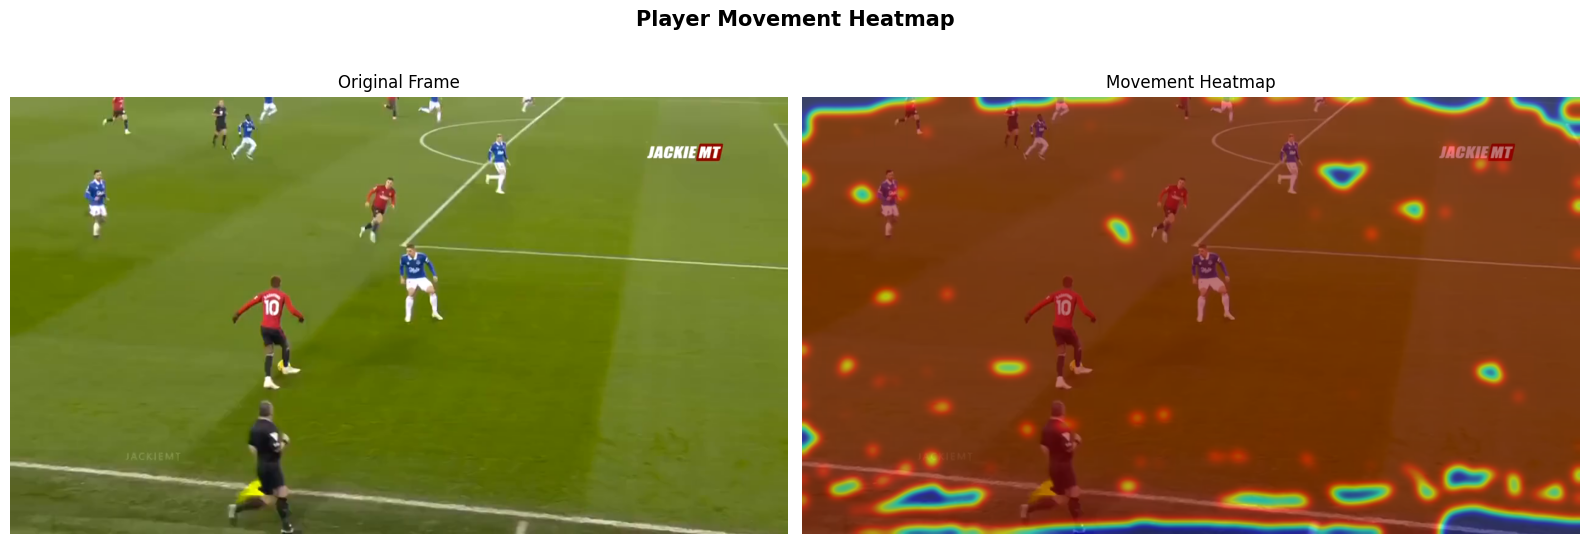

✅ Heatmap saved


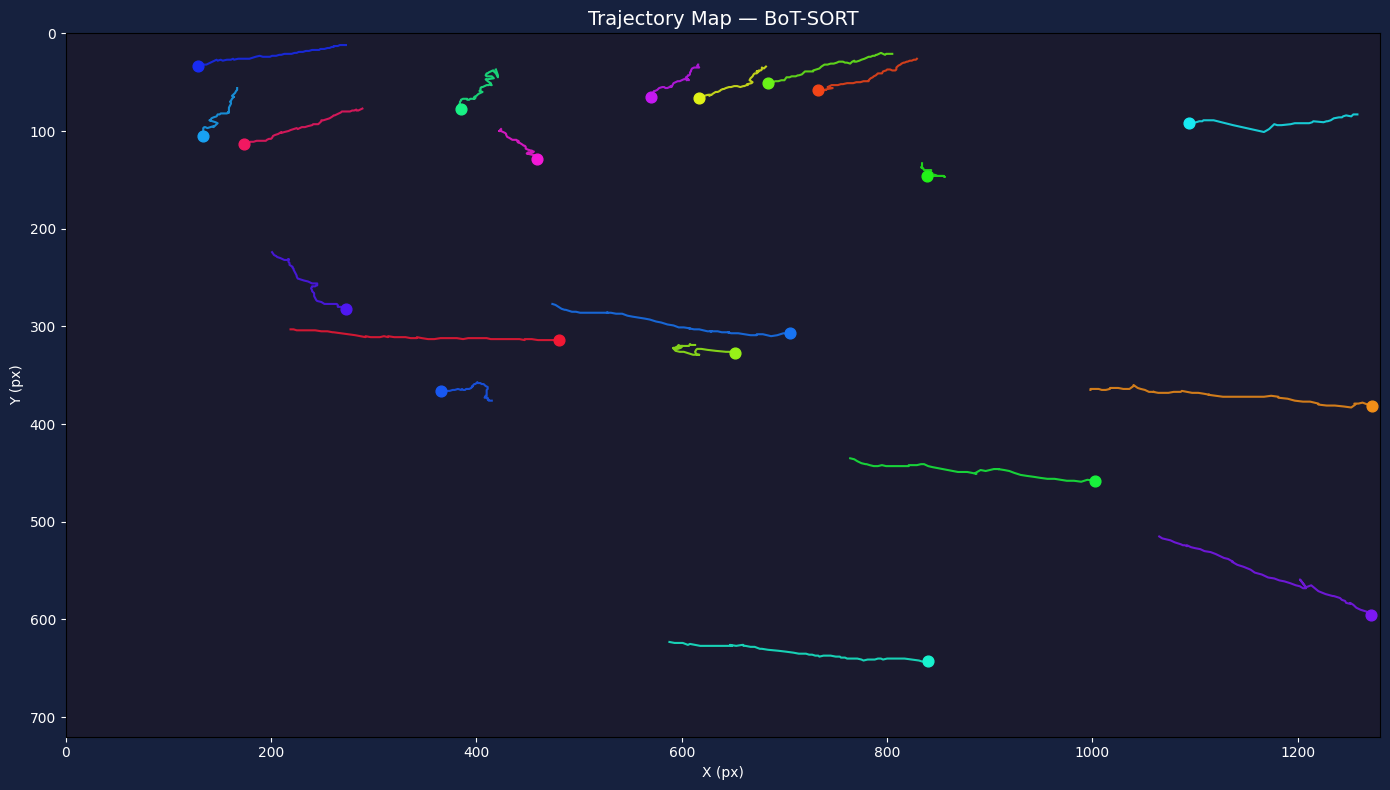

✅ Trajectory saved


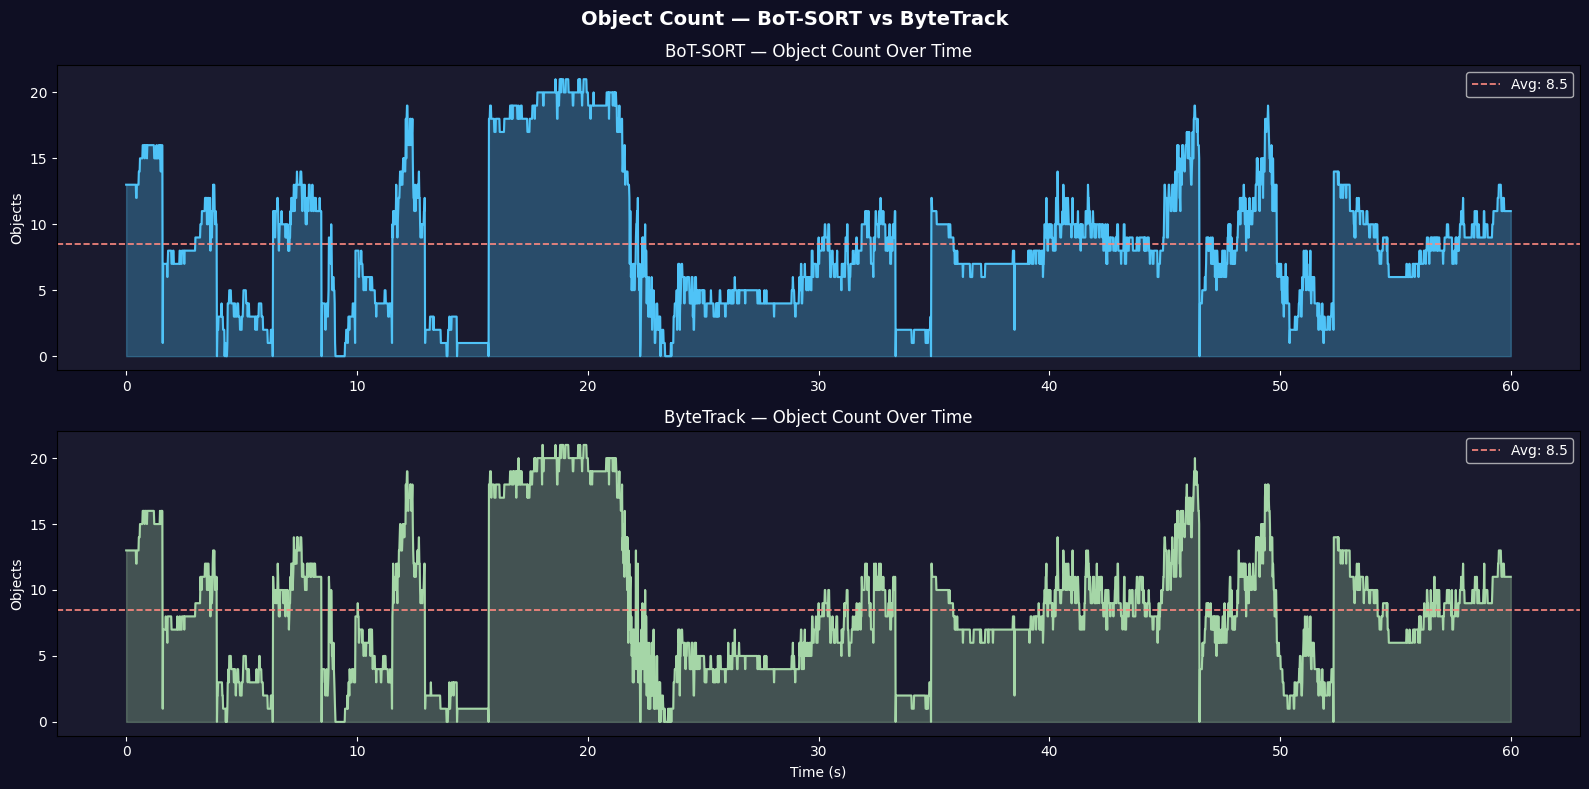

✅ Count plot saved


In [9]:

import matplotlib.pyplot as plt
import cv2, numpy as np, colorsys

def save_heatmap(heatmap_acc, video_path, save_path):
    blurred = cv2.GaussianBlur(heatmap_acc, (51, 51), 0)
    norm    = cv2.normalize(blurred, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    colored = cv2.applyColorMap(norm, cv2.COLORMAP_JET)
    cap = cv2.VideoCapture(video_path)
    _, bg = cap.read(); cap.release()
    bg = cv2.resize(bg, (heatmap_acc.shape[1], heatmap_acc.shape[0]))
    blended = cv2.addWeighted(bg, 0.45, colored, 0.55, 0)
    cv2.imwrite(save_path, blended)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(cv2.cvtColor(bg, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original Frame'); axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)); axes[1].set_title('Movement Heatmap'); axes[1].axis('off')
    plt.suptitle('Player Movement Heatmap', fontsize=15, fontweight='bold')
    plt.tight_layout(); plt.savefig(save_path, dpi=130, bbox_inches='tight'); plt.show()
    print(f"✅ Heatmap saved")

save_heatmap(stats_primary['heatmap_acc'], RAW_VIDEO_PATH, HEATMAP_PATH)

def plot_trajectories(track_history, video_path, save_path, max_ids=20):
    cap = cv2.VideoCapture(video_path)
    vw = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    vh = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    golden = 0.618033988749895
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_facecolor('#1a1a2e'); fig.patch.set_facecolor('#16213e')
    for tid in sorted(track_history.keys())[:max_ids]:
        trail = track_history[tid]
        if len(trail) < 3: continue
        xs = [p[0] for p in trail]; ys = [p[1] for p in trail]
        hue = (tid * golden) % 1.0
        r, g, b = colorsys.hsv_to_rgb(hue, 0.9, 0.95)
        ax.plot(xs, ys, color=(r,g,b), linewidth=1.5, alpha=0.85, label=f"ID {tid}")
        ax.scatter(xs[-1], ys[-1], color=(r,g,b), s=60, zorder=5)
    ax.set_xlim(0, vw); ax.set_ylim(vh, 0)
    ax.set_xlabel('X (px)', color='white'); ax.set_ylabel('Y (px)', color='white')
    ax.set_title('Trajectory Map — BoT-SORT', color='white', fontsize=14)
    ax.tick_params(colors='white')
    if len(track_history) <= 15:
        ax.legend(loc='upper right', fontsize=8, ncol=2, facecolor='#1a1a2e', labelcolor='white')
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show(); print("✅ Trajectory saved")

plot_trajectories(stats_primary['track_history'], RAW_VIDEO_PATH, TRAJECTORY_PATH)

def plot_counts(counts1, counts2, fps, save_path):
    t1 = [i/fps for i in range(len(counts1))]
    t2 = [i/fps for i in range(len(counts2))]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8))
    fig.patch.set_facecolor('#0f0f23')
    for ax in [ax1, ax2]:
        ax.set_facecolor('#1a1a2e'); ax.tick_params(colors='white')
        ax.xaxis.label.set_color('white'); ax.yaxis.label.set_color('white')
        ax.title.set_color('white')
    ax1.fill_between(t1, counts1, alpha=0.3, color='#4fc3f7')
    ax1.plot(t1, counts1, color='#4fc3f7', lw=1.5)
    ax1.axhline(sum(counts1)/len(counts1), color='#ff8a80', ls='--', lw=1.2, label=f"Avg: {sum(counts1)/len(counts1):.1f}")
    ax1.set_title('BoT-SORT — Object Count Over Time'); ax1.set_ylabel('Objects'); ax1.legend(facecolor='#1a1a2e', labelcolor='white')
    ax2.fill_between(t2, counts2, alpha=0.3, color='#a5d6a7')
    ax2.plot(t2, counts2, color='#a5d6a7', lw=1.5)
    ax2.axhline(sum(counts2)/len(counts2), color='#ff8a80', ls='--', lw=1.2, label=f"Avg: {sum(counts2)/len(counts2):.1f}")
    ax2.set_title('ByteTrack — Object Count Over Time'); ax2.set_ylabel('Objects'); ax2.set_xlabel('Time (s)')
    ax2.legend(facecolor='#1a1a2e', labelcolor='white')
    plt.suptitle('Object Count — BoT-SORT vs ByteTrack', color='white', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig(save_path, dpi=130, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show(); print("✅ Count plot saved")

cap = cv2.VideoCapture(RAW_VIDEO_PATH)
fps_v = cap.get(cv2.CAP_PROP_FPS) or 30.0; cap.release()
plot_counts(stats_primary['per_frame_counts'], stats_secondary['per_frame_counts'], fps_v, COUNT_PLOT_PATH)

In [10]:

import pandas as pd

def id_switch_proxy(counts):
    return sum(1 for i in range(1, len(counts)) if abs(counts[i]-counts[i-1]) > 2)

p, s = stats_primary, stats_secondary
data = {
    'BoT-SORT': [
        p['frame_count'], f"{p['proc_fps']:.1f}", p['total_unique_ids'],
        max(p['per_frame_counts']), f"{sum(p['per_frame_counts'])/len(p['per_frame_counts']):.1f}",
        id_switch_proxy(p['per_frame_counts']), 'Yes (GMC + ReID)', 'Yes (GMC)',
    ],
    'ByteTrack': [
        s['frame_count'], f"{s['proc_fps']:.1f}", s['total_unique_ids'],
        max(s['per_frame_counts']), f"{sum(s['per_frame_counts'])/len(s['per_frame_counts']):.1f}",
        id_switch_proxy(s['per_frame_counts']), 'No (IoU only)', 'No',
    ],
}
index = ['Frames', 'Speed (FPS)', 'Total Unique IDs', 'Max Simultaneous',
         'Avg Per Frame', 'ID Switch Proxy', 'Appearance ReID', 'Camera Compensation']

df = pd.DataFrame(data, index=index)
print("\n" + "="*55)
print("       TRACKER COMPARISON")
print("="*55)
print(df.to_string())
print("="*55)
df.to_csv(f'{PROJECT_DIR}/tracker_comparison.csv')
print("✅ Saved to Drive")


       TRACKER COMPARISON
                             BoT-SORT      ByteTrack
Frames                           3600           3600
Speed (FPS)                      10.8           16.0
Total Unique IDs                  412            630
Max Simultaneous                   21             21
Avg Per Frame                     8.5            8.5
ID Switch Proxy                    88            129
Appearance ReID      Yes (GMC + ReID)  No (IoU only)
Camera Compensation         Yes (GMC)             No
✅ Saved to Drive


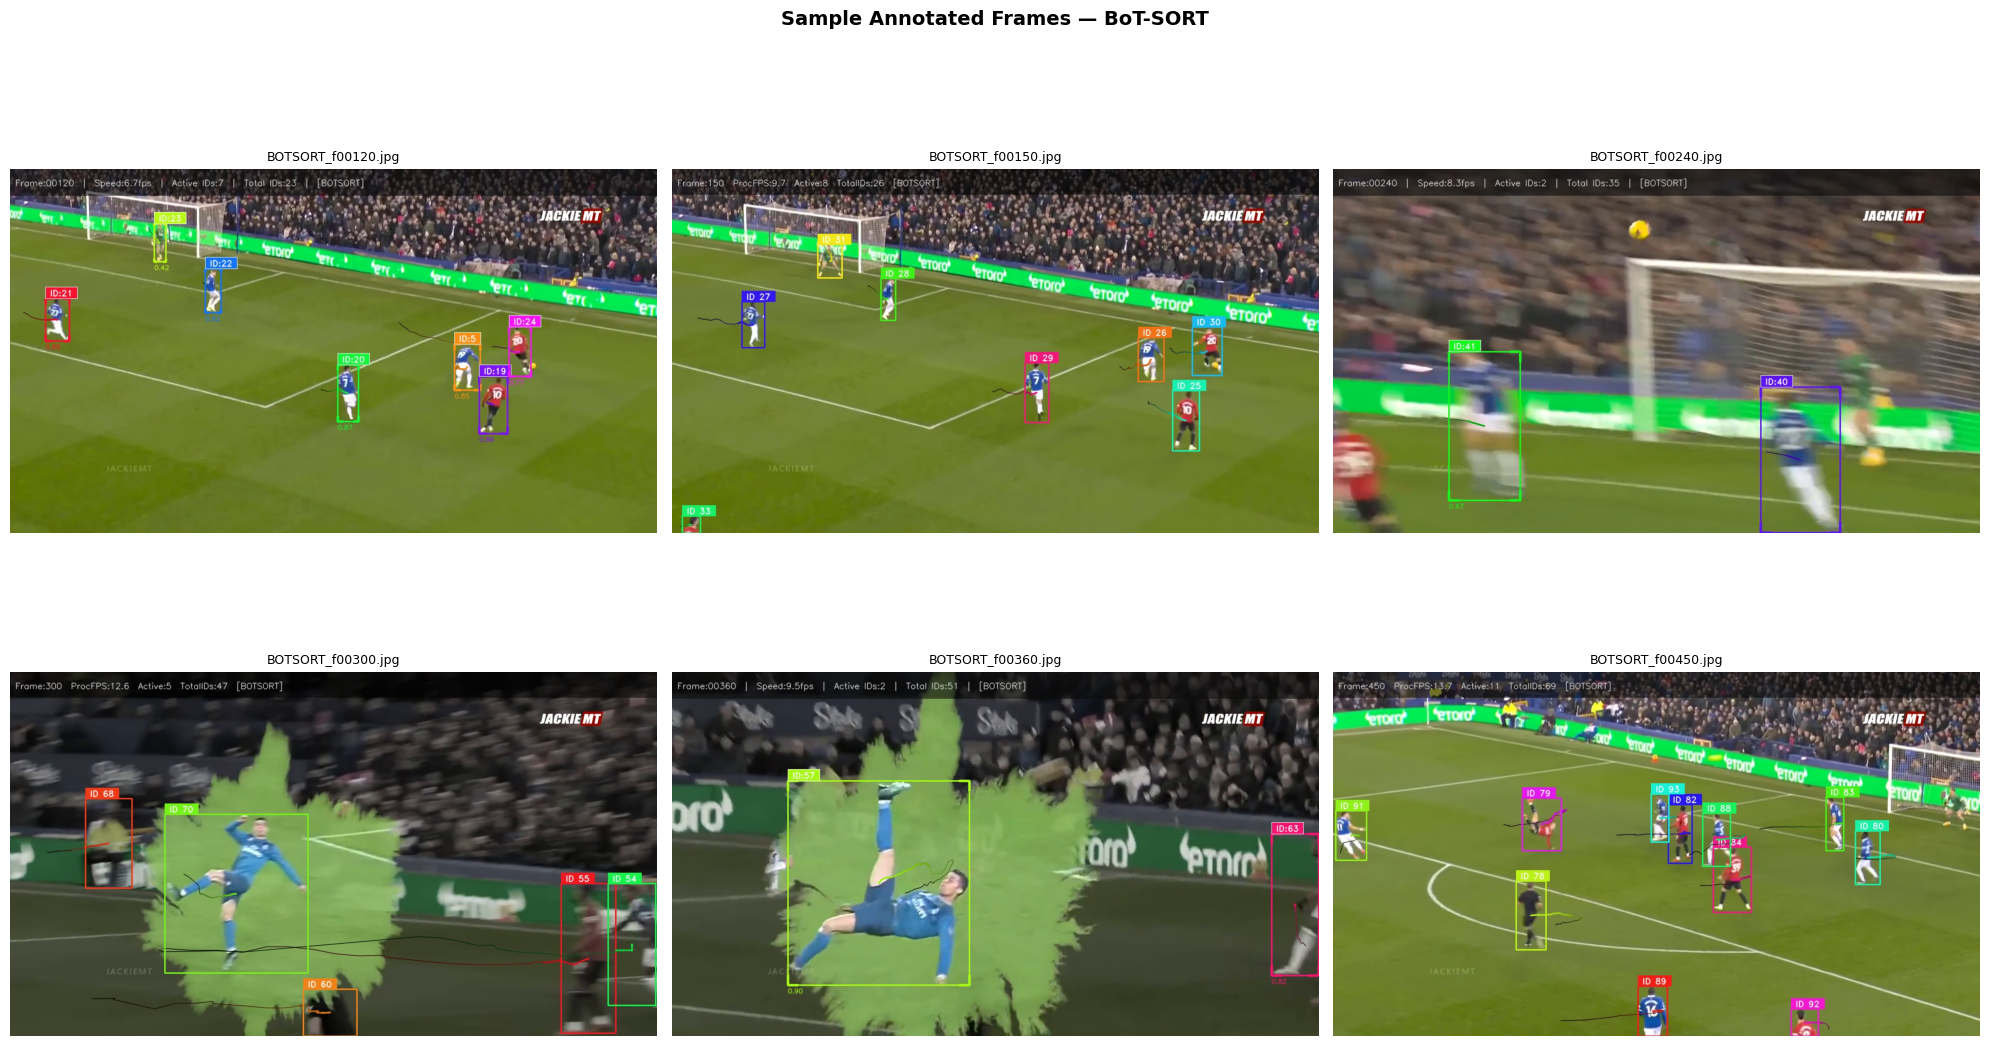

In [11]:

import matplotlib.pyplot as plt, matplotlib.image as mpimg, glob, os

files = sorted(glob.glob(f'{SCREENSHOT_DIR}/BOTSORT_*.jpg'))[:6]
if files:
    n = len(files); cols = min(n,3); rows = (n+cols-1)//cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows*6))
    axes = axes.flatten() if n > 1 else [axes]
    for ax, path in zip(axes, files):
        ax.imshow(mpimg.imread(path)); ax.set_title(os.path.basename(path), fontsize=9); ax.axis('off')
    for ax in axes[n:]: ax.set_visible(False)
    plt.suptitle('Sample Annotated Frames — BoT-SORT', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{SCREENSHOT_DIR}/sample_grid.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print("No screenshots yet — screenshots save every 150 frames during Cell 7")

In [12]:

import os

files = [
    (OUTPUT_PRIMARY,   "Annotated video (BoT-SORT)"),
    (OUTPUT_SECONDARY, "Annotated video (ByteTrack)"),
    (HEATMAP_PATH,     "Movement heatmap"),
    (TRAJECTORY_PATH,  "Trajectory map"),
    (COUNT_PLOT_PATH,  "Object count plot"),
    (f'{PROJECT_DIR}/tracker_comparison.csv', "Comparison CSV"),
]
print("\n" + "="*60)
print("  🏆  ALL DONE — DELIVERABLES")
print("="*60)
print(f"{'Deliverable':<40} {'Size':>10}")
print("-"*52)
for path, label in files:
    if os.path.exists(path):
        print(f"{label:<40} {os.path.getsize(path)/1e6:>8.2f} MB")
    else:
        print(f"{label:<40} {'MISSING':>10}")
print("\n📁 All saved to:", PROJECT_DIR)
print("🎉 Ready for submission!")


  🏆  ALL DONE — DELIVERABLES
Deliverable                                    Size
----------------------------------------------------
Annotated video (BoT-SORT)                 135.44 MB
Annotated video (ByteTrack)                136.13 MB
Movement heatmap                             0.61 MB
Trajectory map                               0.08 MB
Object count plot                            0.21 MB
Comparison CSV                               0.00 MB

📁 All saved to: /content/drive/MyDrive/sports_tracking_project
🎉 Ready for submission!
